# Analysis of Global UHI Data
By Josh Houlding

Urban Heat Islands (UHIs) are a phenomenon in which the surface and air temperatures of urban areas are higher than those of surrounding suburban and rural areas due to factors like increased prevalence of manmade materials, higher energy use, and industrial activity. Dense and highly developed cities such as New York City, Phoenix, Tokyo, and Delhi are especially vulnerable to UHIs. They can be mitigated by increasing green space coverage within cities and installing infrastructure such as cool roofs. This project aims to predict and model UHIs in cities worldwide using publicly available datasets, uncovering trends and patterns that can inform sustainable urban planning and public health policy, as well as guide mitigation strategies like increasing green space and implementing cool roof technologies.

This notebook contains an analysis of a dataset acquired from NASA's [SEDAC (Socioeconomic Data and Applications Center)](https://earthdata.nasa.gov/data/catalog/sedac-ciesin-sedac-sdei-uhi2013-1.00) containing data on land area, population, day-night temperature differences, and so on for tens of thousands of cities worldwide. This data provides the opportunity to uncover links between a city's demographic and geographic characteristics and its UHI intensities, highlighting the most important factors in UHI formation.

<b>Central analysis question:</b> What are the most important factors driving the formation of UHIs?

# Loading and Cleaning the Data

In [31]:
import pandas as pd

In [32]:
# Load data
df = pd.read_csv("sdei-global-uhi-2013/sdei-global-uhi-2013.csv")

In [33]:
# View data
print(f"Data shape: {df.shape}")
df.head()

Data shape: (31500, 17)


,ISOURBID,ISO3,URBID,NAME,SCHNM,ES90POP,ES95POP,ES00POP,SQKM_FINAL,URB_D_MEAN,BUF_D_MEAN,D_T_DIFF,URB_N_MEAN,BUF_N_MEAN,N_T_DIFF,LATITUDE,LONGITUDE
0,GRL8,GRL,8,Upernavik,UPERNAVIK,918,1015.0,1123,4.93,7.05,7.95,-0.90,-3.16,-1.66,-1.50,72.788598,-56.140056
1,USA15,USA,15,Barrow,BARROW,3469,3986.0,4581,152.21,10.65,12.41,-1.76,-0.45,0.80,-1.25,71.303963,-156.730206
2,NOR17,NOR,17,Honningsvåg,HONNINGSVAG,2237,2356.0,2510,47.58,16.66,14.53,2.13,5.43,6.72,-1.29,71.004989,25.962568
3,NOR19,NOR,19,Hav?ysund,HAVOYSUND,1285,1235.0,1163,19.44,14.61,14.87,-0.26,5.61,5.75,-0.14,70.983068,24.652803
4,NOR21,NOR,21,Kj?llefjord,KJOLLEFJORD,1159,1115.0,1049,35.16,20.33,18.24,2.09,4.57,6.96,-2.40,70.943870,27.356392


### Variable details

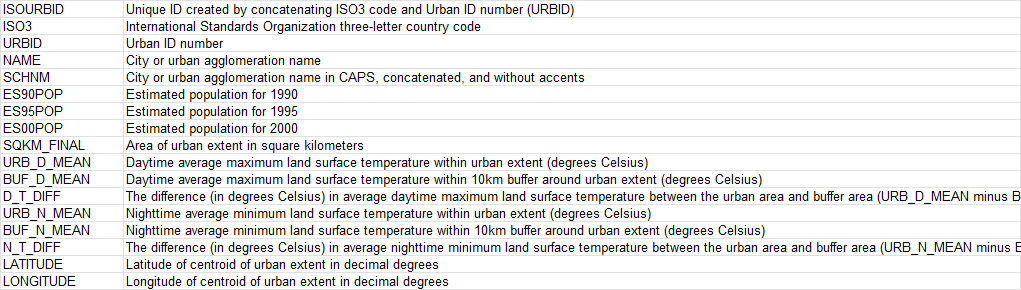

This is a large dataset, so for the sake of pipeline and model performance, we will filter it down to cities with over 100,000 residents. This has the added benefit of limiting the analysis to cities that are likely to have significant UHI effects, have higher-quality data available, and are more relevant to policymakers, urban planners and environmentalists.

In [34]:
# Filter dataset down to cities with at least 100k residents
df = df[df["ES00POP"] >= 100000]

# Show new dataset shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (3519, 17)


### Dropping unnecessary columns

We will simply use the agglomeration name, `SCHNM`, instead of `NAME` because it is free of special characters. The 1990 and 1995 population estimates are also not necessary because no time series analysis is possible with this data.

In [35]:
# Function to cleanly print items in a list
def print_items(list):
    cols = ""
    for i in range(0, len(list)):
        if i == len(list) - 1:
            cols = cols + list[i]
        else:
            cols = cols + list[i] + ", "
    cols = cols + "."
    return cols

# Drop columns
columns_to_drop = ["NAME", "ES90POP", "ES95POP"]
print(f"Dataframe columns before dropping: {print_items(df.columns)}\n")
df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped the following columns {print_items(columns_to_drop)}\n")
print(f"Dataframe columns after dropping: {print_items(df.columns)}")

Dataframe columns before dropping: ISOURBID, ISO3, URBID, NAME, SCHNM, ES90POP, ES95POP, ES00POP, SQKM_FINAL, URB_D_MEAN, BUF_D_MEAN, D_T_DIFF, URB_N_MEAN, BUF_N_MEAN, N_T_DIFF, LATITUDE, LONGITUDE.

Dropped the following columns NAME, ES90POP, ES95POP.

Dataframe columns after dropping: ISOURBID, ISO3, URBID, SCHNM, ES00POP, SQKM_FINAL, URB_D_MEAN, BUF_D_MEAN, D_T_DIFF, URB_N_MEAN, BUF_N_MEAN, N_T_DIFF, LATITUDE, LONGITUDE.


### Renaming columns
Column names in all lowercase with underscores separating words are easier to read and type out than the default all-caps names we find in this dataset by default.

In [36]:
# Create new column mapping
new_column_mapping = {"ISOURBID": "isourbid", "ISO3": "iso3", "URBID": "urbid", "SCHNM": "name", "ES00POP": "pop_2000", 
                      "SQKM_FINAL": "area_sq_km", "URB_D_MEAN": "urban_day_mean", "BUF_D_MEAN": "buffer_day_mean", 
                      "D_T_DIFF": "day_diff", "URB_N_MEAN": "urban_night_mean", "BUF_N_MEAN": "buffer_night_mean", 
                      "N_T_DIFF": "night_diff", "LATITUDE": "latitude", "LONGITUDE": "longitude"}

# Apply new column mapping
print(f"Old column names: {print_items(df.columns)}\n")
df.rename(columns=new_column_mapping, inplace=True)
print(f"New column names: {print_items(df.columns)}")

Old column names: ISOURBID, ISO3, URBID, SCHNM, ES00POP, SQKM_FINAL, URB_D_MEAN, BUF_D_MEAN, D_T_DIFF, URB_N_MEAN, BUF_N_MEAN, N_T_DIFF, LATITUDE, LONGITUDE.

New column names: isourbid, iso3, urbid, name, pop_2000, area_sq_km, urban_day_mean, buffer_day_mean, day_diff, urban_night_mean, buffer_night_mean, night_diff, latitude, longitude.


### Feature engineering
A column for density should be created because denser cities usually have more intense UHI effects due to denser human activity. We will explore this more later. 

In [37]:
# Create column for population per square kilometer
df["pop_per_sq_km"] = df["pop_2000"] / df["area_sq_km"]

### Checking data types
We must ensure that all text variables are in object format, and all numeric variables are in some form of int or float format.

In [38]:
# View data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3519 entries, 22 to 31434
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   isourbid           3519 non-null   object 
 1   iso3               3519 non-null   object 
 2   urbid              3519 non-null   int64  
 3   name               3519 non-null   object 
 4   pop_2000           3519 non-null   int64  
 5   area_sq_km         3519 non-null   float64
 6   urban_day_mean     3519 non-null   float64
 7   buffer_day_mean    3519 non-null   float64
 8   day_diff           3519 non-null   float64
 9   urban_night_mean   3512 non-null   float64
 10  buffer_night_mean  3518 non-null   float64
 11  night_diff         3512 non-null   float64
 12  latitude           3519 non-null   float64
 13  longitude          3519 non-null   float64
 14  pop_per_sq_km      3519 non-null   float64
dtypes: float64(10), int64(2), object(3)
memory usage: 439.9+ KB


All data types are appropriate, so no conversions are required.

### Handling duplicates
Duplicate entries must be removed from this dataset because each city in the dataset only requires a single entry, and thus every duplicate is necessarily an error.

In [39]:
# Drop duplicates
print(f"Original entry count: {len(df)}")
df = df.drop_duplicates()
print(f"Dropped all duplicate entries.")
print(f"Entry count after dropping duplicates: {len(df)}")

Original entry count: 3519
Dropped all duplicate entries.
Entry count after dropping duplicates: 3519


No duplicates were present in this data, but it's always worthwhile to check in cases like this.

### Handling missing values
Missing values must be dealt with to improve data quality and thus improve the model's effectiveness.

In [40]:
# Show missing value count per column
print(f"Entries with missing values: {df.isna().sum().sum()}. \n")
print(f"Missing value count by column: \n {df.isna().sum()}")

Entries with missing values: 15. 

Missing value count by column: 
 isourbid             0
iso3                 0
urbid                0
name                 0
pop_2000             0
area_sq_km           0
urban_day_mean       0
buffer_day_mean      0
day_diff             0
urban_night_mean     7
buffer_night_mean    1
night_diff           7
latitude             0
longitude            0
pop_per_sq_km        0
dtype: int64


We will fill these missing values with K-nearest neighbors (KNN) imputation, as this is a powerful algorithm that uses adjacent data points to optimize the filled value, ensuring higher-quality data than if we used simple imputation like the mean or median.

After this, we will recalculate `day_diff` and `night_diff`, as their values depend on the three mean columns in the code below.

In [41]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Select columns to standardize and impute
columns_to_impute = ["urban_night_mean", "buffer_night_mean"]

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[columns_to_impute])

# Apply KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="uniform")  # Or weights="distance"
df_imputed = imputer.fit_transform(df_scaled)

# Reverse scaling to original scale
df[columns_to_impute] = scaler.inverse_transform(df_imputed)

# Impute missing values with the mean
#df["urban_day_mean"].fillna(df["urban_day_mean"].mean(), inplace=True)
df["urban_night_mean"].fillna(df["urban_night_mean"].mean(), inplace=True)
df["buffer_night_mean"].fillna(df["buffer_night_mean"].mean(), inplace=True)
print(f"Imputed missing values in columns {columns_to_impute}.")

# Recalculate day_diff and night_diff
#df["day_diff"] = df["urban_day_mean"] - df["buffer_day_mean"]
df["night_diff"] = df["urban_night_mean"] - df["buffer_night_mean"]

# Show missing value count per column
print(f"Entries with missing values: {df.isna().sum().sum()}.")

Imputed missing values in columns ['urban_night_mean', 'buffer_night_mean'].
Entries with missing values: 0.


### Analyzing descriptive statistics

In [42]:
# Show descriptive statistics
df.describe()

,urbid,pop_2000,area_sq_km,urban_day_mean,buffer_day_mean,day_diff,urban_night_mean,buffer_night_mean,night_diff,latitude,longitude,pop_per_sq_km
count,3519.000000,3.519000e+03,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000
mean,43733.753339,6.114347e+05,612.080097,37.729147,36.523396,1.205669,19.417025,18.891927,0.525097,26.706504,46.835555,inf
std,19790.985888,2.023355e+06,1430.981070,6.689391,7.254590,1.897051,5.210294,5.222653,0.894329,20.437819,69.667364,NaN
min,96.000000,1.000320e+05,0.000000,17.720000,17.690000,-11.170000,-10.010000,-5.940000,-10.010000,-53.126794,-157.940495,47.261438
25%,31944.000000,1.335085e+05,105.505000,32.990000,31.335000,0.180000,15.685000,14.945000,0.130000,16.835476,7.021522,581.577028
50%,44668.000000,2.127080e+05,242.920000,36.820000,35.120000,1.290000,20.450000,20.080000,0.530000,31.131872,60.002876,1135.616010
75%,55209.500000,4.314945e+05,590.810000,41.325000,40.270000,2.280000,23.460000,23.020000,0.930000,40.112908,111.776009,1967.045763
max,94585.000000,7.858290e+07,43605.800000,62.510000,61.840000,10.630000,28.670000,27.840000,8.030000,69.321546,176.861014,inf


The max values for `urban_day_mean` and `urban_night_mean` are about 62.5°C (144.5°F), which is higher than any surface temperature ever recorded on Earth ([56.7°C in Death Valley, CA, USA](https://en.wikipedia.org/wiki/Highest_temperature_recorded_on_Earth#:~:text=According%20to%20the%20World%20Meteorological%20Organization%20%28WMO%29%2C%20the,registered%20on%2013%20September%201922%2C%20in%20%CA%BDAziziya%2C%20Libya.)). Thus, it is sensible to cap daytime temperatures at 56.7°C.

In [43]:
import numpy as np

# Cap daytime temperatures at global record
df["urban_day_mean"] = np.where(df["urban_day_mean"] > 56.7, 56.7, df["urban_day_mean"])
df["buffer_day_mean"] = np.where(df["buffer_day_mean"] > 56.7, 56.7, df["urban_day_mean"])
print(f"Capped temperature values at 56.7 degrees Celsius.")

Capped temperature values at 56.7 degrees Celsius.


### Handling outliers
Extreme outliers in a dataset can signficantly affect the performance of machine learning models trained on it. Thus, these should be handled appropriately.

We will use percentile clipping, AKA winsorization, to "eliminate" outliers by capping low values at the 5th percentile and high values at the 95th percentile for each column. This is preferable to removing outliers outright because it does not cause any loss of data.

In [44]:
# Select columns to clip
#"""
cols_to_clip = ["pop_2000", "area_sq_km", "urban_day_mean", "buffer_day_mean", "day_diff", "urban_night_mean", "buffer_night_mean",
                "night_diff"]

# Save copy of dataframe before clipping (for model testing later)
#df_unclipped = df.copy()

# Clip values at 5th and 95th percentiles
for col in df[cols_to_clip]:  # Select numeric columns other than latitude and longitude
    lower_bound = np.percentile(df[col], 5)  # 5th percentile
    upper_bound = np.percentile(df[col], 95)  # 95th percentile
    df[col] = np.clip(df[col], lower_bound, upper_bound)
print(f"Low outliers set to the 5th percentile value, and high outliers set to the 95th percentile value.")
#""";

# Set main dataframe variable back to unclipped dataframe (for model testing later)
#df = df_unclipped

Low outliers set to the 5th percentile value, and high outliers set to the 95th percentile value.


With that, our data preprocessing is now complete, and we can make a backup of the clean dataframe and then start exploring it.

In [45]:
# Create backup of clean original dataframe
df_backup = df

# Export clean dataset
df.to_csv("UHI_SEDAC_data_clean.csv")

In [46]:
# Show final dataframe
print(df.head())

   isourbid iso3  urbid         name  pop_2000  area_sq_km  urban_day_mean  \
22    NZL96  NZL     96     HASTINGS  113497.0      346.34           32.96   
23   CHL101  CHL    101     VALDIVIA  124590.0      180.26           28.51   
37   CHL125  CHL    125       OSORNO  128430.0      280.58           35.07   
51   NZL155  NZL    155   WELLINGTON  480770.0      754.77           28.24   
61   CHL183  CHL    183  PUERTOMONTT  143354.0      172.34           29.31   

    buffer_day_mean  day_diff  urban_night_mean  buffer_night_mean  \
22            32.96      2.14             12.15             12.060   
23            28.51      1.38             11.03             10.830   
37            35.07      1.24             10.75             10.299   
51            28.24      3.61             10.75             10.299   
61            29.31      2.35             10.75             10.299   

    night_diff   latitude   longitude  pop_per_sq_km  
22        0.09 -39.507647  176.861014     327.703990  


# Exploring the Data
Here, we will be checking things such as:
* The distributions of variables.
* Correlations between variables.
* Which countries and cities experience the strongest and weakest UHI effects, and why.
* A map of cities showing the intensity of their UHI effects.

We will focus our efforts on the features and label for the model later on, which need to be selected.

<b>Label:</b> What we're trying to predict. In this case, `night_diff` makes the most sense, since the best indicator of a city's UHI intensity is how well it holds onto heat at nighttime compared to the buffer zones around it. <br>
<b>Features:</b> Several numeric variables other than `night_diff`. We will start with `pop_2000`, `area_sq_km`, `day_diff`, `latitude`, and `longitude`. Some other variables have been omitted (`urban_day_mean` and `buffer_day_mean`, for example) because `day_diff` is the difference between the two, and multicollinearity problems could arise if we include all of them in the model.

### Variable distributions

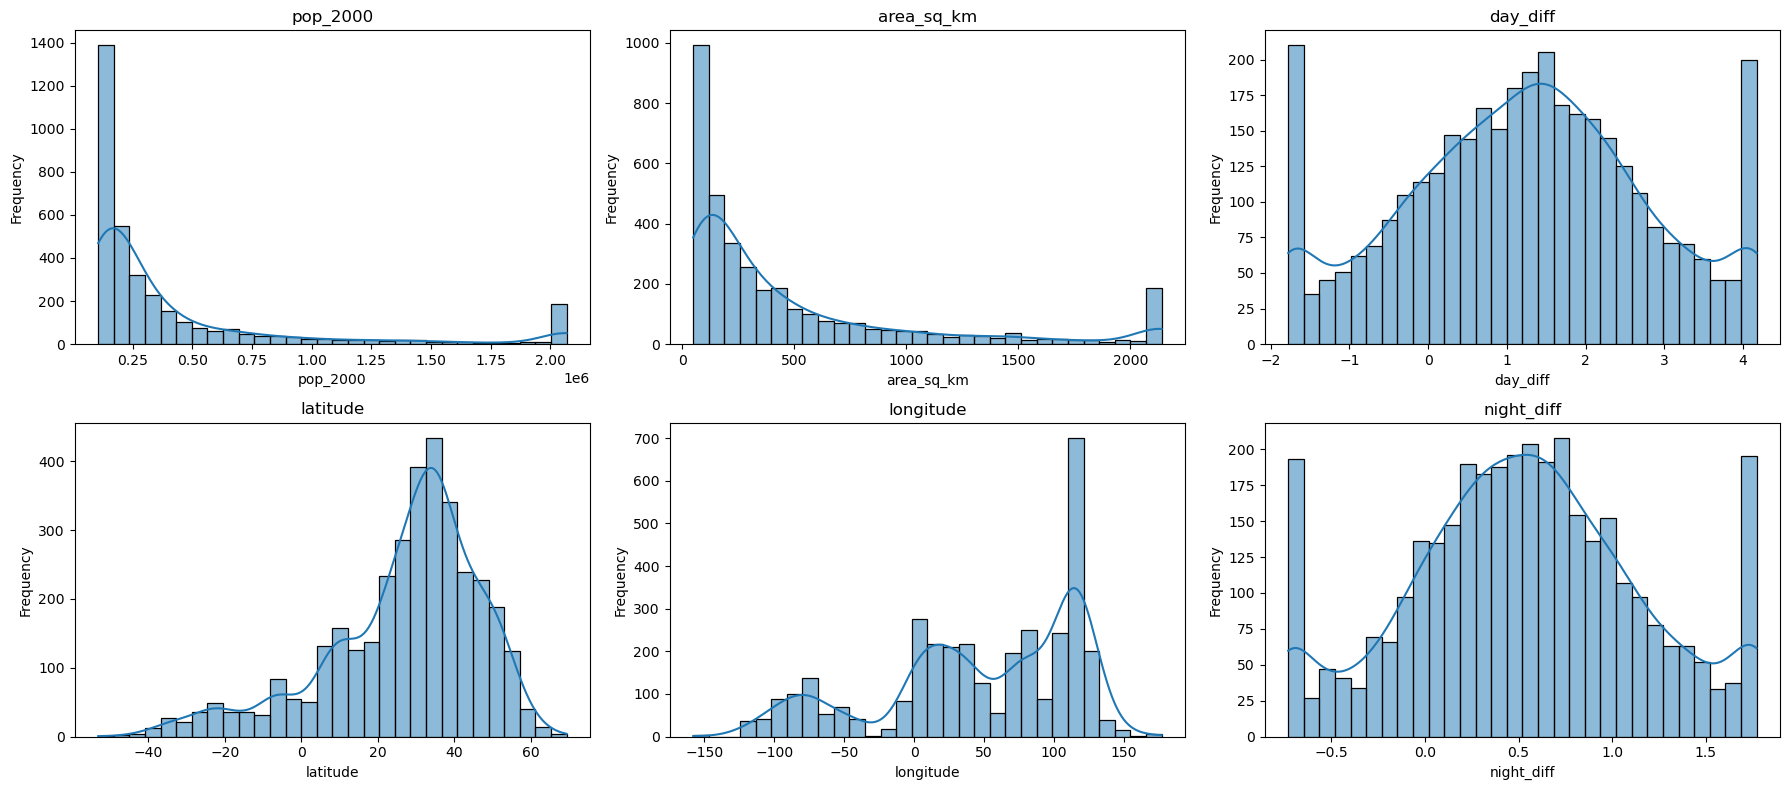

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select columns to plot
columns = ['pop_2000', 'area_sq_km', 'day_diff', 'latitude', 'longitude', 'night_diff']

# Set up figure and axes
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(columns):
    sns.histplot(df[column], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()

We see a normal distribution for `day_diff` and `night_diff` as expected, with high frequencies at the low and high ends that result from the winsorization we performed on outliers earlier. Latitude has a left-skewed distribution, reflecting the higher density of cities in the northern hemisphere. Longitude displays three prominent humps, the left one presumably being for North America, the middle for Europe, and the right one for Asia.

### Feature correlations
We will look at the correlations between every pair of features, as well as between the features and the label, `night_diff`.

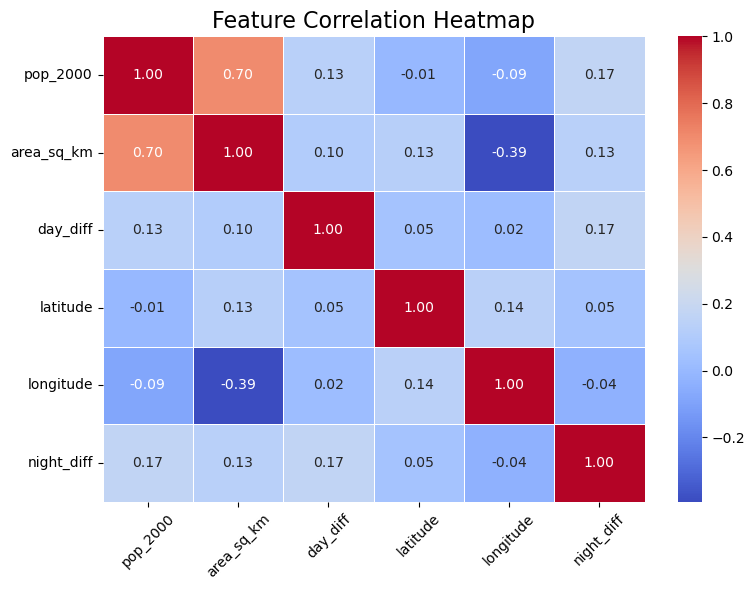

In [48]:
# Select features
features = ['pop_2000', 'area_sq_km', 'day_diff', 'latitude', 'longitude', 'night_diff']

# Compute the correlation matrix
correlation_matrix = df[features].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True,  # Display correlation values
    cmap='coolwarm',  # Choose a color palette
    fmt='.2f',  # Format the annotation text
    linewidths=0.5,  # Add lines between cells
    cbar=True  # Show the color bar
)

# Add a title
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Display the plot
plt.tight_layout()
plt.show()

We see a moderate linear relationship between the land area of a city and its population, which is sensible. All other feature correlations are fairly weak, which is a good sign because it means multicollinearity will not be a significant issue.

The feature with the highest correlation coefficient with `night_diff` is `day_diff`, which make sense. If a city has a significant temperature difference between its urban core and its surroundings during the day, then this phenomenon is likely to continue into the nighttime as well.

### UHIs by country
Because `night_diff` represents how much cooler the city surface is at night compared to the daytime on average, larger values indicate stronger UHI effects due to the temperature not changing much, which is because manmade surfaces, buildings, vehicles, etc. are holding onto heat effectively at night.

In [49]:
# Find mean nighttime temp. difference by country
mean_nd_by_country = df.groupby("iso3")["night_diff"].mean().to_frame().reset_index()

# Find 5 countries with most and least intense UHI effects respectively
top_5_worst_UHI = mean_nd_by_country.sort_values(by="night_diff", ascending=False).head(5)
top_5_best_UHI = mean_nd_by_country.sort_values(by="night_diff", ascending=True).head(5)

# Display results
print(f"The 5 countries with the most severe UHI effects: \n {top_5_worst_UHI} \n")
print(f"The 5 countries with the least severe UHI effects: \n {top_5_best_UHI}")

The 5 countries with the most severe UHI effects: 
     iso3  night_diff
133  RWA       1.771
130  REU       1.771
9    BDI       1.771
129  QAT       1.750
5    ARM       1.655 

The 5 countries with the least severe UHI effects: 
    iso3  night_diff
16  BHS       -0.73
98  MLT       -0.73
91  MAC       -0.73
44  ERI       -0.73
15  BHR       -0.72


The five countries exhibiting the most pronounced Urban Heat Island (UHI) effects are Rwanda (RWA), Reunion (REU), Burundi (BDI), Qatar (QAT), and Armenia (ARM). Observing a notable average nighttime temperature differential, these nations, though geographically diverse, share characteristics that contribute to elevated UHI. Rwanda, Burundi, and Armenia, while not as geographically small as some previous high-ranking locations, still feature densely populated urban centers with limited green spaces. Qatar, a rapidly developing nation, is also experiencing an increase in urban density. Reunion, an island territory, experiences unique microclimates that may be exacerbating the UHI effect.

Conversely, the five countries displaying the least severe UHI effects are the Bahamas (BHS), Malta (MLT), Macao (MAC), Eritrea (ERI), and Bahrain (BHR). These locations, predominantly islands or coastal nations, benefit from the thermal moderating influence of large bodies of water. The consistent maritime climate, characterized by the high heat capacity of water, effectively buffers temperature fluctuations, leading to minimal nighttime temperature differences. Furthermore, some of these locations, such as the Bahamas, possess significant natural vegetation, further mitigating the formation of intense urban heat islands.

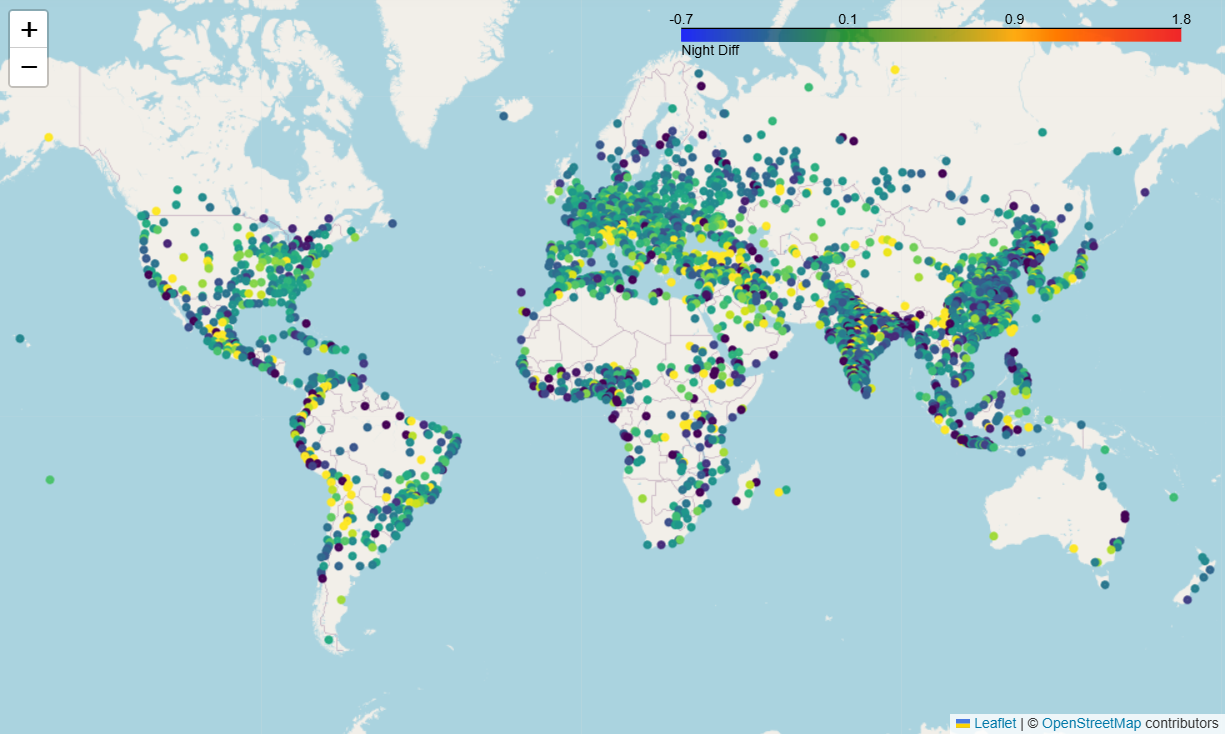

In [50]:
#"""
import folium
from matplotlib import cm, colors
import branca.colormap as bcm
from IPython.display import Image

# Take subset of dataset
data = df[["name", "pop_2000", "latitude", "longitude", "night_diff"]]

# Cap values at the 95th percentile
threshold = min(np.percentile(data["night_diff"], 95), 12)  # Use 12°C as a max reasonable limit
data.loc[:, "night_diff"] = np.clip(data["night_diff"], None, threshold)

# Normalize night_diff for color mapping
norm = colors.Normalize(vmin=data["night_diff"].min(), vmax=data["night_diff"].max())
colormap = cm.ScalarMappable(norm=norm, cmap="viridis")

# Create a linear colormap for the legend
linear_colormap = bcm.LinearColormap(
    ['blue', 'green', 'orange', 'red'],
    vmin=data["night_diff"].quantile(0.05),
    vmax=data["night_diff"].quantile(0.95),
    caption="Night Diff"
)

# Create a Folium map
m = folium.Map(location=[data["latitude"].mean(), data["longitude"].mean()], zoom_start=2)

# Add individual markers with dynamic color mapping
for _, row in data.iterrows():
    color = colors.rgb2hex(colormap.to_rgba(row["night_diff"]))  # Convert RGBA to hex
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=2,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        tooltip=f"{row['name']}: Night Diff {row['night_diff']:.2f}"
    ).add_to(m)

# Add the colormap to the map
linear_colormap.add_to(m)

# Save the interactive map as a HTML file
m.save("UHI_map_dynamic.html")

# Show the map
Image("UHI Map.PNG")
#""";

Upon looking at this map, we observe a clear pattern of heightened Urban Heat Island (UHI) effects concentrated in specific regions, revealing a complex interplay of socioeconomic, climatic, and policy-related factors.

* **Regional Hotspots & Urban Disparities:**
    * UHI effects are concentrated in Latin America, the Middle East, South Asia, and parts of Southern Europe, correlating with rapid, unplanned urbanization and limited mitigation resources.
    * To address this, prioritize investments in sustainable urban infrastructure (green roofs, parks, cool materials) and implement equitable zoning policies that prioritize vulnerable communities.

* **Climate Vulnerability & Environmental Justice:**
    * Hot climates and prolonged heat waves exacerbate UHI, disproportionately impacting vulnerable populations with limited access to cooling.
    * Enhance climate adaptation by developing heat action plans, establishing early warning systems, and creating accessible cooling centers.

* **Policy & Sustainable Development:**
    * Historical urban development patterns and a lack of robust planning policies contribute to UHI.
    * Implement building codes mandating sustainable features, incentivize green initiatives, and foster community-led planning to create resilient urban environments.

### Spatial Autocorrelation Analysis

We investigated whether cities near each other exhibit similar Urban Heat Island (UHI) effects, hypothesizing they would due to shared local climate and urban practices.

A Mantel test was used, correlating geographic distance with UHI intensity differences, to quantify this.

The hypotheses of this test are the following:
* $H_0$ (Null Hypothesis): No correlation between geographic distance and UHI differences. <br>
* $H_a$ (Alternative Hypothesis): Cities closer together have more similar UHI.

This test helps determine if spatial autocorrelation exists in our UHI data.

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def mantel_test(df, value_col, lat_col, lon_col, num_permutations=1000):
    """
    Performs a Mantel test to assess spatial autocorrelation.

    Args:
        df: Pandas DataFrame containing your data.
        value_col: Name of the column with the values to analyze.
        lat_col: Name of the latitude column.
        lon_col: Name of the longitude column.
        num_permutations: Number of permutations for significance testing.

    Returns:
        A tuple containing the Mantel correlation coefficient and p-value.
    """

    # 1. Create spatial distance matrix
    coords = df[[lon_col, lat_col]].values
    spatial_dist_matrix = distance.cdist(coords, coords, 'euclidean')

    # 2. Create difference matrix
    value_diff_matrix = distance.pdist(df[value_col].values.reshape(-1, 1), 'euclidean')
    value_diff_matrix = distance.squareform(value_diff_matrix)

    # 3. Perform the Mantel test
    observed_r, _ = pearsonr(spatial_dist_matrix.flatten(), value_diff_matrix.flatten())

    # Permutation test for significance
    permuted_r = []
    for _ in range(num_permutations):
        permuted_values = np.random.permutation(df[value_col].values)
        permuted_diff_matrix = distance.pdist(permuted_values.reshape(-1, 1), 'euclidean')
        permuted_diff_matrix = distance.squareform(permuted_diff_matrix)
        r, _ = pearsonr(spatial_dist_matrix.flatten(), permuted_diff_matrix.flatten())
        permuted_r.append(r)

    p_value = np.mean(np.array(permuted_r) >= observed_r)

    return observed_r, p_value

# Find autocorrelation values
mantel_df = df.sample(1000, random_state=42) # Take random sample of 1,000 cities for improved performance
mantel_r, mantel_p = mantel_test(mantel_df, 'night_diff', 'latitude', 'longitude')
print(f"Mantel's r: {mantel_r}")
print(f"p-value: {mantel_p}")

The Mantel test results indicate a weak positive spatial autocorrelation (Mantel's r = 0.0246) with a statistically significant p-value less than 0.05. This suggests that while there is some evidence of spatial clustering in the data, the relationship between spatial distance and the variable of interest is weak. In other words, nearby data points tend to have slightly more similar values than those farther apart, but the effect is small.

# Modeling the Data

To understand and predict Urban Heat Island (UHI) effects, we developed and evaluated regression models. Model performance was primarily assessed using Root Mean Squared Error (RMSE).

RMSE was chosen as the primary evaluation metric due to its sensitivity to larger prediction errors. In the context of UHI analysis, accurately predicting extreme temperature variations is crucial, as these deviations can have significant impacts on public health and energy consumption. RMSE's ability to amplify these larger deviations provides a robust measure of the model's reliability in capturing critical temperature fluctuations. Additionally, RMSE is expressed in the same units as the dependent variable (temperature difference), making it easily interpretable and directly relevant to our research objectives.

### Normalizing numeric features
Normalizing numeric variables is essential for model performance, as it scales features to a common range, preventing variables with larger magnitudes from dominating. This process improves algorithm convergence and enhances model interpretability by allowing for fairer comparisons of feature importance, particularly when variables are measured in different units.

Additionally, to rigorously evaluate the model's performance and ensure its ability to generalize to unseen data, we partitioned the dataset into training and testing sets. The training set was used to develop and fit the model, while the testing set served as an independent benchmark to assess its predictive accuracy and identify potential overfitting.

In [ ]:
def prepare_data(df, features, test_size=0.2, random_state=42):
    """
    Selects features, normalizes them, and splits the data into training and testing sets.

    Args:
        df (pd.DataFrame): The input DataFrame.
        features (list): List of feature column names.
        label_col (str, optional): The name of the label column. Defaults to "night_diff".
        test_size (float, optional): The proportion of the dataset to include in the test split. Defaults to 0.2.
        random_state (int, optional): Controls the shuffling applied to the data before applying the split. Defaults to 42.

    Returns:
        tuple: A tuple containing x_train, x_test, y_train, y_test.
    """

    # Select features and label
    x = df[features].copy()
    y = df["night_diff"].copy()

    # Initialize scaler and normalize features
    scaler = MinMaxScaler()
    x[features] = scaler.fit_transform(x[features])

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)

    # Show shapes of training and testing sets
    print(f"Shape of x_train: {x_train.shape}")
    print(f"Shape of x_test: {x_test.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of y_test: {y_test.shape}")

    return x_train, x_test, y_train, y_test

Having been cleaned and normalized, the data is now ready for basic regression modeling.

### Model 1: Linear regression model w/ initial feature set
We initiated our modeling process with a linear regression model due to its inherent simplicity and computational efficiency. Linear regression provides a baseline understanding of the relationships between our predictor variables and UHI effects. Its straightforward implementation allows for rapid prototyping and initial insights, serving as a foundation for comparison with more complex models.

This initial feature set, consisting of a city's population, land area, daytime temperature difference, latitude and longitude, was chosen because we hypothesized these features would be the best predictors of nighttime temperature difference.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Create and fit LR model
model = LinearRegression()
features = ["pop_2000", "area_sq_km", "day_diff", "latitude", "longitude"]
x_train, x_test, y_train, y_test = prepare_data(df, features)
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

### Evaluating the model
To rigorously assess the overall statistical significance of our linear regression model (and future models as well), we will now compute the F-statistic. This test will determine whether the model, as a whole, has significant predictive power beyond what would be expected by chance, indicating if there's a meaningful relationship between our predictors and UHI effects.

In [ ]:
# Function to calculate the F-statistic of a model
def calculate_f_statistic():
    
    # Calculate components of F-statistic
    n = x_train.shape[0]  # Number of observations
    p = x_train.shape[1]  # Number of predictors
    tss = np.sum((y_train - np.mean(y_train))**2) # Total sum of squares (TSS)
    sse = np.sum((y_test - y_pred)**2) # Residual sum of squares (SSE)
    ssr = tss - sse # Explained sum of squares (SSR)
    df_model = p # Model degrees of freedom
    df_residual = n - p - 1 # Residual degrees of freedom
    ms_model = ssr / df_model  # Mean square for the model
    ms_residual = sse / df_residual  # Mean square for residuals

    # Calculate F-statistic
    f_statistic = ms_model / ms_residual
    print(f"F-statistic: {f_statistic} \n")
    
# Find F-statistic for linear regression model
calculate_f_statistic()

The high F-statistic obtained from our analysis provides strong evidence that our linear regression model's predictions are significantly better than what would be expected from random guessing. This result indicates that the model captures meaningful relationships between the predictor variables and the UHI effect, demonstrating its overall statistical significance and predictive power.

Next, we will evaluate the model's predictive performance using several key metrics, each providing unique insights into the model's strengths and limitations. Specifically, we will examine:

* **Root Mean Square Error (RMSE):** To quantify the average magnitude of prediction errors, with a focus on penalizing larger deviations.
* **Mean Absolute Error (MAE):** To assess the average absolute difference between predicted and actual values, providing a measure of the model's overall accuracy.
* **R-squared:** To determine the proportion of variance in UHI explained by the model, indicating its goodness of fit.
* **Adjusted R-squared:** To account for the number of predictors in the model, providing a more conservative measure of fit and preventing overfitting.

By analyzing these metrics, we aim to gain a thorough understanding of the model's predictive capabilities and its suitability for our UHI analysis.

In [ ]:
# Calculate and display RMSE and MAE
print(f"Model Evaluation Metrics:")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

# Calculate and display R^2 and adjusted R^2
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}") 
n = len(y_test)
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
print(f"Adjusted R²: {adj_r2} \n")

# Find and display model coefficients
intercept = model.intercept_
coefficients = model.coef_
feature_names = x_train.columns
print(f"Feature Importance Analysis:")
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
print(f"{coef_df} \n")

The linear regression model shows limited predictive power, with an R-squared of 0.043 and moderate errors (RMSE 0.619, MAE 0.493). 
* `pop_2000` has a very small positive coefficient. Cities with more people have more human activity and manmade infrastructure, leading to higher nighttime temperatures.
* `area_sq_km` has a small negative coefficient. That is to say, bigger, more spread-out cities have less intense UHI effects due to lower concentrations of manmade materials and human activity.
* `day_diff` has the largest absolute coefficient of any variable in the model. Hotter cities have more intense UHI effects.
* `latitude` has a slightly positive coefficient, indicating that cities further from the equator (larger absolute latitude coordinates) experience more intense UHI effects. This is a counterintuitive result that warrants further analysis.
* `longitude` has a slightly negative coefficient, indicating that cities further from the prime meridian (through Greenwich, England) have less intense UHI effects. 

We will also conduct k-fold cross-validation with 5 folds to gauge how well the model generalizes to unseen data. $k=5$ provides an effective balance between computational efficiency and rigor.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Function for performing 5-fold cross-validation
def perform_cross_validation(model):
    print("K-fold cross-validation:")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores  # Convert negative RMSE back to positive RMSE
    print("RMSE Scores:", rmse_scores)
    print("Mean RMSE:", np.mean(rmse_scores))
    print("Standard Deviation of RMSE:", np.std(rmse_scores))
    
perform_cross_validation(model)

#### REWRITE

The average cross-fold RMSE is about 0.244 degrees Celsius, which is almost identical to the RMSE of 0.247 calculated earlier.

The model's average cross-fold RMSE of 0.244 degrees Celsius means our predictions are, on average, 0.244 degrees off the actual nighttime temperature differences. To understand the significance of this error, we need to examine the range and distribution of the `night_diff` data.

In [ ]:
# Show nighttime temperature stats
df["night_diff"].describe().to_frame().transpose()

The mean `night_diff` is about 0.5°C, meaning the model's accuracy, with an RMSE of 0.24°C, is decent but far from flawless. This will require further examination.

We will now create a residual plot to scan for systemic patterns. If any are detected, it might indicate that the model is not capturing the relationships properly.

#### Residual Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted night_diff")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We see a downward trend among the residuals as predictions get larger, especially at the top and bottom of the spread, which are presumably the outliers that were capped at the 5th and 95th percentiles earlier. This heteroscedasticity (unequal scatter of residuals) warrants additional exploration.

#### NOTE: These values are from a previous version of the data, but the findings are likely to translate over to the new version as well.

To measure the effects of the capped values on model performance, we temporarily suspended capping/winsorization during data preprocessing, and recorded the findings below:

#### Evaluation metrics (no capping)
RMSE: 0.9097484021014357 <br>
MAE: 0.5816001356514385 <br>
R²: 0.03165828987178876 <br>
Adjusted R²: 0.024721744670297197

#### Evaluation metrics (capping)
RMSE: 0.6188222065358749 <br>
MAE: 0.4928358576499527 <br>
R²: 0.04292362516229853 <br>
Adjusted R²: 0.03606777720500831 

We see that capping significantly decreases RMSE and MAE, indicating better model accuracy due to smaller errors, and that it increases R-squared and adjusted R-squared, indicating a better fit to the data. Thus, capping is a necessary and useful preprocessing step that should remain in the pipeline.

To explore potential improvements in predictive accuracy, we experimented with Random Forest regression and ensemble methods, including gradient boosting.

The following table shows the RMSE values for each model:

<table>
    <tr>
        <td><b>Model</b></td>
        <td><b>RMSE</b></td>
    </tr>
    <tr>
        <td>Linear Regression</td>
        <td>0.6188</td>
    </tr>
    <tr>
        <td>Random Forest Regressor</td>
        <td>0.6038</td>
    </tr>
    <tr>
        <td>Ensemble Regressor w/ Gradient Boosting</td>
        <td>0.6011</td>
    </tr>
    </table>
    
Given the marginal improvement in RMSE achieved by the Random Forest and ensemble models, coupled with their increased computational demands, we determined that the linear regression model provided the most efficient and practical solution for this analysis. Its simplicity and interpretability, combined with its adequate performance, make it the optimal choice for our project's objectives. While the residuals suggest potential under-prediction at extreme values, the linear model effectively captures the primary trends within the data.

Code for the additional models (random forest and ensemble) can be found at the very bottom of this notebook.

# Key Findings and Real-World Implications

**1. Key Predictors of Nighttime UHI:**

* **Daytime Temperature Differences (`day_diff`):**
    * Both the heatmap and the linear regression model identified daytime temperature differences as a significant predictor of nighttime UHI.
    * **Implication:** It is crucial for cities to implement strategies that reduce daytime heat absorption, such as increasing urban green spaces and implementing cool roofs and reflective materials in construction.
    * **Impact:** Reducing daytime surface temperatures could have a cascading effect on nighttime UHI.
* **Land Area (`area_sq_km`):**
    * The heatmap indicated land area as a strong predictor.
    * **Implication:** Larger cities with extensive built environments must consider the scale of development when strategizing on how to implement green infrastructure for UHI mitigation.
* **Geographic Location (Latitude and Longitude):**
    * The linear regression model found latitude and longitude to be influential.
    * **Observation:** Cities farther from the equator had more intense UHI effects, and cities farther from the prime meridian had less intense UHI effects.

**2. Model Limitations and Future Research:**

* **Limited Predictive Power:**
    * The limited R-squared value of the model indicates that other factors not captured by the model are likely influencing UHI.
    * **Necessity for Further Research:** Further research is needed to explore the complex interplay of environmental, socioeconomic, and urban design factors that contribute to UHI effects.
* **Global vs. Local Analysis:**
    * Our global analysis provides a broad overview of UHI patterns.
    * **Importance of Localized Studies:** Localized studies will be crucial for developing targeted mitigation strategies in various cities.

**3. Overall Implications:**

* The findings highlight the importance of considering both daytime heat absorption and urban development scale in UHI mitigation efforts.
* While this global model provides valuable insights, it serves as a foundation for more detailed, localized analyses.
* Further research is needed to improve the model's predictive power and to identify additional factors that contribute to UHI.

### Model 2: Random Forest Regressor

In [ ]:
"""
from sklearn.ensemble import RandomForestRegressor

# Initialize and fit model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

# Calculate F-statistic
calculate_f_statistic()

# Make predictions and evaluate the model
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Random Forest RMSE: {rmse}")
""";

We see basically no improvement in RMSE from the linear regression model from the random forest. Thus, we will try an ensemble of multiple models and evaluate its performance.

### Model 3: Ensemble Regressor
Our initial ensemble will include a linear regression model, a random forest, an XGBoost algorithm, and a ridge regression model.

In [ ]:
"""
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# Define models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)
ridge_model = Ridge(alpha=1.0)

# Train models
lr_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)
xgb_model.fit(x_train, y_train)
ridge_model.fit(x_train, y_train);

# Create and fit ensemble model
model = VotingRegressor(estimators=[
    ('lr', lr_model),
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('ridge', ridge_model)
])
model.fit(x_train, y_train);

# Calculate F-statistic
calculate_f_statistic()

# Make predictions and evaluate the model
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Ensemble RMSE: {rmse}")
""";